# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [ ]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

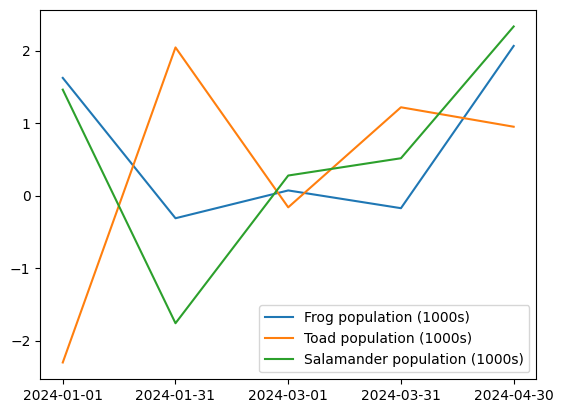

In [ ]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

Instead of including scale on the legend, it could also be shown on the y axis. Also I cannot understand logistically how the population can be negative unless it is a change in population rather than absolute amount. Clearly stating that in the title would help. Finally the axis axis can be simplified to only include the month and add the year to the title of x axis label

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

In [35]:
df = pd.read_csv('Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [36]:
df[['BorrowerState', 'InitialApprovalAmount']]

,BorrowerState,InitialApprovalAmount
0,48.0,769358.78
1,48.0,736927.79
2,48.0,691355.00
3,48.0,499871.00
4,48.0,367437.00
...,...,...
968527,56.0,150000.00
968528,56.0,150000.00
968529,56.0,150000.00
968530,56.0,150000.00


In [ ]:
import scipy.stats as stats

In [43]:
t_stat, p_value = stats.ttest_ind(df[df['BorrowerState'] == 1][['InitialApprovalAmount']], df[df['BorrowerState'] == 2][['InitialApprovalAmount']])
p_value

array([0.00060805])

In [45]:
u_value, p_value = stats.mannwhitneyu(df[df['BorrowerState'] == 1][['InitialApprovalAmount']], df[df['BorrowerState'] == 2][['InitialApprovalAmount']])
p_value

array([0.02684116])

In [ ]:
import scipy.stats as stats
state_1 = df[df['BorrowerState'] == 1][['BorrowerState', 'InitialApprovalAmount']]
state_2 = df[df['BorrowerState'] == 2][['BorrowerState', 'InitialApprovalAmount']]
state_3 = df[df['BorrowerState'] == 3][['BorrowerState', 'InitialApprovalAmount']]

result = stats.f_oneway(state_1, state_2, state_3)
print(result.pvalue)

[0.         0.00101224]


c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\scipy\stats\_axis_nan_policy.py:618: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


In [42]:
result = stats.chi2_contingency(df[['BorrowerState', 'InitialApprovalAmount']])
print(result.pvalue)

0.0


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

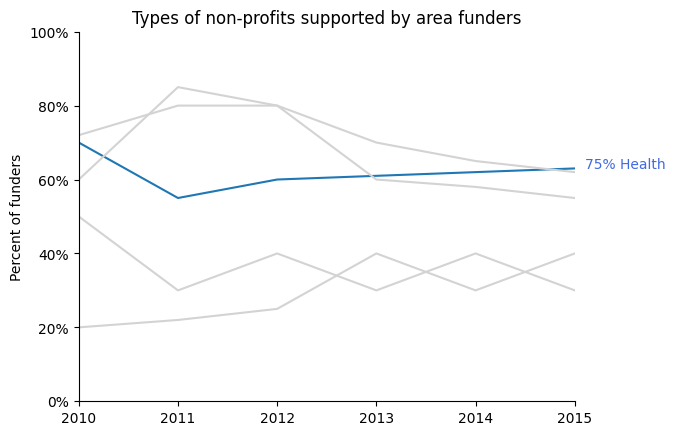

In [34]:
# Figure 9.22 Page 229
import matplotlib.ticker as mtick

fig, ax = plt.subplots()

xs = [0,1,2,3,4,5]
ax.plot(xs, [.7, .55, .6, .61, .62, .63])
ax.plot(xs, [.2, .22, .25, .4, .3, .4], color='lightgray')
ax.plot(xs, [.5, .3, .4, .3, .4, .3], color='lightgray')
ax.plot(xs, [.6, .85, .8, .6, .58, .55], color='lightgray')
ax.plot(xs, [.72, .8, .8, .7, .65, .62], color='lightgray')

plt.xlim(0, 5)
plt.ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.xticks([0,1,2,3,4,5], ['2010', '2011', '2012', '2013', '2014', '2015'])

plt.ylabel("Percent of funders")
plt.title("Types of non-profits supported by area funders")
plt.text(5.1, .63, "75% Health", color='royalblue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
None